# **Introduction**
This demonstration will show a basic workflow showing the programs capabilities. It will also deliberately trigger errors to show some defensive programming realizations.  
&rarr; Based on optimized features future hotel prices with three different room classes are optimized to maximize revenue.  

&rarr; Note that for each class and method a docstring is provided!

# **Importing the Library**
First we must add the path of the folder where the package is located to the system path:

In [ ]:
import sys
from pathlib import Path
import os

# Defining the path were this file is currently located
current_path = Path.cwd().resolve()

# Adding the current_path to the system-path
sys.path.append(str(current_path))
print(os.getcwd())

Now we can import the package:

In [2]:
from hotel_po import price_optimization as po

**Important**: Once the library is loaded we will get excess to all created classes. The pipeline of the intended workflow using this package is the following:  
1. Data
2. (Overview) &rarr; Not necessarily required
3. Features
4. ModelRF
5. PriceOptimization  

The reduce the *obligated* workload the user is also able to start directly from the Overview or Features class, because both inherit the ```__init__``` from the Data class which automatically creates all neccessary data which is needed by the Overview or Features classes. Also the data check is done through the ```__init__``` from the Data class.  

In the following we will make use of this shortcut and start directly from the Overview class:

# **Data Overview (Overview class)**
By providing the path of the data as an instance-attribute the Overview class will directly make use of the inherited ```__init__``` from the Data class. This will only work if the path is valid and a raw-string or written with \\\\. Informative errors are returned otherwise. For example:

In [3]:
overview = po.Overview(123)

TypeError: The path must be a string.

Now we import the synthetic data correctly:

In [4]:
overview = po.Overview('synthetic_hotel_data.csv')

Now we have different attributes and methods available. First we look at the raw data by accessing it via an attribute:

In [5]:
display(overview.data_agg.head())
display(overview.data_agg["room_class"].unique())

,arrival_date,room_class,month,week,day,is_holiday,is_weekend,total_demand,mean_price,mean_lead_time
0,2018-01-01,1,1,1,1,1,0,14,475.358571,44.571429
1,2018-01-01,2,1,1,1,1,0,20,309.257500,49.700000
2,2018-01-01,3,1,1,1,1,0,20,187.898000,47.200000
3,2018-01-02,1,1,1,2,0,0,10,349.453000,61.500000
4,2018-01-02,2,1,1,2,0,0,17,217.222353,46.823529


array([1, 2, 3])

Within the ```__init``` we made use of the ```aggregate()``` method which aggregates the data by arrival_date and room_class => We have direct access to it as well. For example only the aggregated data of room_class 1:

In [6]:
display(overview.data_1.head())

,arrival_date,room_class,month,week,day,is_holiday,is_weekend,total_demand,mean_price,mean_lead_time
arrival_date,,,,,,,,,,
2018-01-01,2018-01-01,1,1,1,1,1,0,14,475.358571,44.571429
2018-01-02,2018-01-02,1,1,1,2,0,0,10,349.453000,61.500000
2018-01-03,2018-01-03,1,1,1,3,0,0,9,339.527778,48.888889
2018-01-04,2018-01-04,1,1,1,4,0,0,9,332.181111,39.555556
2018-01-05,2018-01-05,1,1,1,5,0,0,11,333.390909,41.090909


Also other methods are available, such as:

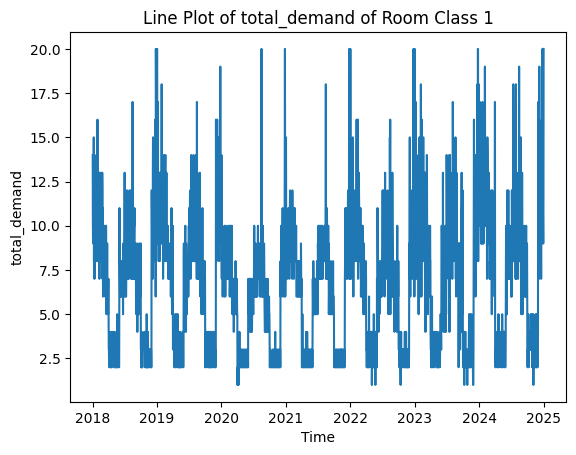

In [7]:
overview.vis_line(room_class=1, column="total_demand")

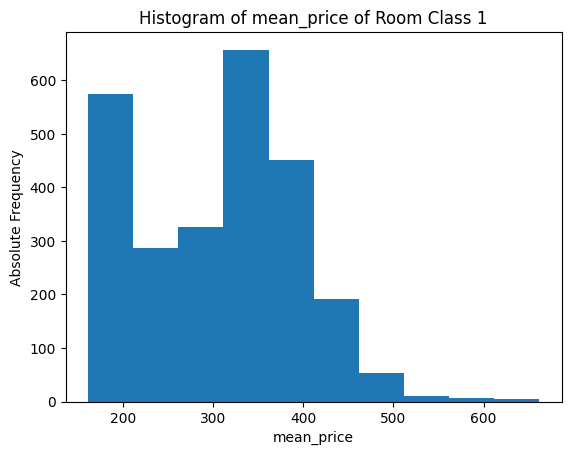

In [8]:
overview.vis_hist(room_class=1, column="mean_price")

In [9]:
overview.stat_overview(room_class=1)

,arrival_date,room_class,month,week,day,is_holiday,is_weekend,total_demand,mean_price,mean_lead_time
count,2558,2558.0,2558.000000,2558.0,2558.000000,2558.000000,2558.000000,2558.000000,2558.000000,2558.000000
mean,2021-07-02 11:59:59.999999744,1.0,6.520328,26.542611,15.725176,0.035966,0.285379,6.736904,305.983503,36.238171
min,2018-01-01 00:00:00,1.0,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,161.360000,2.000000
25%,2019-10-02 06:00:00,1.0,4.000000,13.25,8.000000,0.000000,0.000000,3.000000,217.005000,23.500000
50%,2021-07-02 12:00:00,1.0,7.000000,27.0,16.000000,0.000000,0.000000,7.000000,319.926032,37.464286
75%,2023-04-02 18:00:00,1.0,10.000000,40.0,23.000000,0.000000,1.000000,9.000000,370.204286,47.500000
max,2025-01-01 00:00:00,1.0,12.000000,53.0,31.000000,1.000000,1.000000,20.000000,661.551500,95.125000
std,NaN,0.0,3.450553,15.071189,8.805458,0.186241,0.451683,3.666053,87.939947,15.889937


For demonstration reasons: If we now try to create a ```ModelRF``` class, this won't be possible because we first need to do the feature analysis with the ```Features``` class to extract the features which the model then can be trained on. This forces the user to go with the intended workflow.

In [10]:
fail = po.ModelRF()

TypeError: ModelRF.__init__() missing 1 required positional argument: 'features_object'

# **Extracting Features (Features class)**
This class gets its needed data directly from the Data class since it also inherits its ```__init__```. Means the user could also start the workflow directly from this point if the Overview wasn't important to him/her.    
With the Features Class we will extract and split target and feature variables, be able to analyze the feature correlation and choose the best features based on a feature ranking with RFECV (Model used = Random Forest Regressor).  
**Note**: Within the `correlation` method one choose between plotting the heatmap of the correlation (`plot=True` -> default), or to get the raw correlation data as a pd.DataFrame.

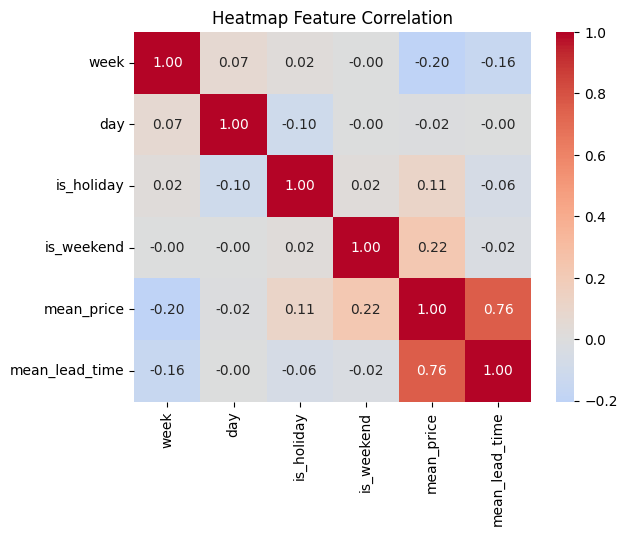

In [11]:
features = po.Features("synthetic_hotel_data.csv")

# When applying the correlation() method, the train_test_split() will be executed
# automatically to ensure the data gets splitted and we don't do data leakage.
# Test-Size = 20% (Default)
features.correlation(room_class=2, plot=True)

By using the ```get_all_final_features()``` method we can extract all best features for all room classes at once by using other class methods automatically such as ```feature_ranking_rfecv()```:  
(With the synthetic dataset this will take approx. 1 Min)

In [ ]:
features.get_all_final_features()

We can have a look on the results since they are being saved as instance-attributes (were None in the initialization and were now overwritten):

In [13]:
display(features.final_X_train_1.head())  # This shows the final features of room class 1

,week,day,is_weekend,mean_price,mean_lead_time
arrival_date,,,,,
2018-01-01,1,1,0,475.358571,44.571429
2018-01-02,1,2,0,349.453000,61.500000
2018-01-03,1,3,0,339.527778,48.888889
2018-01-04,1,4,0,332.181111,39.555556
2018-01-05,1,5,0,333.390909,41.090909


Note that the feature ```is_holiday``` is now excluded because it was redundant within the feature ranking!

# **Creating optimized Models to estimate the Demand with Random Forest Regressor (ModelRF class)**
This class gets its needed data directly from ```features``` object which contains all the needed data. The ```feature``` object must be provided as an instance-attribute - otherwise it won't work.   
The key possibilities with this class are to optimize the hyperparameters of the models for each room class and estimate a final model based on those optimal hyperparameters but complete data set to estimate the demand of that room class with a Random Forest Regressor.  

Getting all optimized hyperparameters (Grid-Search-CV => With the synthetic data set this can take up to 15 Min):

In [14]:
model = po.ModelRF(features_object=features)
model.get_all_optimized_hyperparameters()

Starting Iteration through all room classes.


c:\Users\valti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\valti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\valti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Finished Iteration successfully.


The optimal hyperparameters (and other results) per class were automatically being saved as instance-attributes (were ```None``` before and were now overwritten):

In [15]:
display(model.optimal_model_1["optimal_hyperparams"])     # Optimal Hyperparameters for romm class 1
display(model.optimal_model_1["optimal_mae"])             # MAE of the optimal model for room class 1

{'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 100,
 'random_state': 42}

1.4149576385030382

Based on the optimal model (= model with optimal hyperparameter and the splitted data), we can visualize its results compared to the test data:

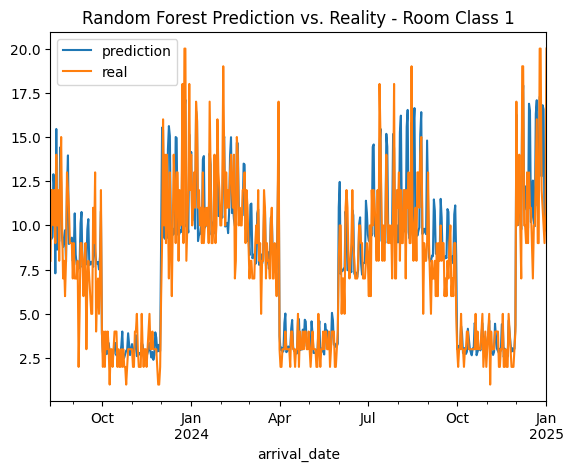

In [16]:
model.optimal_model_vis(room_class=1)

Based on those optimal hyperparameters we can now fit the final model (model with optimal hyperparameters but the complete data set as training data - including only the optimal features of course). This we can also do for all room classes at once:

In [17]:
model.get_all_final_models()

Starting Iteration through all room classes.
Finished Iteration successfully.


We can have a look on the results (mean absolute error) as well:

In [18]:
print(model.final_model_1["mae_on_train"])   # room class 1
print(model.final_model_2["mae_on_train"])   # room class 3
print(model.final_model_3["mae_on_train"])   # room class 3

0.7327211409719087
1.0128099338748129
0.7914977298933177


If we want to get direct access to the final model, we can access it through indexing, where the index is the room_class. For example for room class 1:

In [19]:
print(model[1])

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=2,
                      random_state=42)


# **Price Optimization**
This class gets its needed data directly from the ```model``` object which contains all the needed data. The ```model``` object must be provided as an instance-attribute - otherwise it won't work.   
Finally, for each room class we can optimize the requested price for a date in the future which maximizes the revenue and compare the result with the past to understand if our suggested price makes sense.  

Note: If the date is not in the future, the programm will rise an error!

In [20]:
optimize = po.PriceOptimization(modelrf_object=model, date="2025-02-15")
optimize.get_all_optimized_prices()             # Optimizes all prices at once
optimize.get_all_comparisons()                  # Filters all comparison observations from the training data at once

Starting Iteration through all room classes.
Finished Iteration successfully.
Starting Iteration through all room classes.
Finished Iteration successfully.


In [21]:
display(optimize.optimal_price_1.head())
display(optimize.comparison_1.head())

,demand,revenue,mean_price,week,mean_lead_time
18,14.373126,6899.100438,480,7,45
17,13.359535,6278.981572,470,7,45
16,13.562348,6238.679864,460,7,45
15,13.107582,5898.411793,450,7,45
14,12.515575,5506.852912,440,7,45


,total_demand,revenue,mean_price,week,mean_lead_time
arrival_date,,,,,
2024-02-17,15,7260.36,484.024000,7,44.333333
2023-02-19,15,6779.32,451.954667,7,39.466667
2024-02-18,14,6699.62,478.544286,7,39.500000
2023-02-18,15,6643.30,442.886667,7,31.000000
2024-02-14,14,5946.58,424.755714,7,44.571429


A more summarizing overview of the result can be acchieved by printing the `optimize` object directly:

In [22]:
print(optimize)

--- Optimized Prices for 2025-02-15 ---
Recommended Price for Room Class 1: 480
Recommended Price for Room Class 2: 311
Recommended Price for Room Class 3: 193


Also, the optimized price of room class i can be accessed directly with indexing again where the index is the room class i:

In [23]:
print(optimize[1])

480


# **Automated Pipeline: main() Function**
If the pipeline is not desiered to do manually, one can also use the `main()` function to get to the end-result directly.  
**Note**: The `main()` function returns `None` because it only prints the final optimized prices for each room class for the date desired. => If any more advanced analysis is wanted => Manual approach.

In [27]:
po.main()

Data loaded successfully!

Incorrect format! Please use YYYY-MM-DD (e.g., 2025-05-20).
Date accepted: 2025-05-20

Starting with the Feature Extraction.
Starting Iteration through all room classes.


c:\Users\valti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\valti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\valti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\valti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConvers

Finished Iteration successfully.
Extracted all Features successfully.

Starting with the Model Creation.
Starting Iteration through all room classes.


c:\Users\valti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\valti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\valti\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Finished Iteration successfully.
Starting Iteration through all room classes.
Finished Iteration successfully.
The Model was created successfully!

Starting with the Price Optimization
Starting Iteration through all room classes.
Finished Iteration successfully.
Starting Iteration through all room classes.
Finished Iteration successfully.
Finished Price Optimization successfully.

--- Optimized Prices for 2025-05-20 ---
Recommended Price for Room Class 1: 261
Recommended Price for Room Class 2: 156
Recommended Price for Room Class 3: 95
